In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv(r'C:\Users\kau75421\OneDrive - Viavi Solutions Inc\Desktop\ML AI Reference Document\healthyfy\mobilepllc\data\processed\cleaned_data.csv')

* *1. Correlation Method*  
  *Finds features that have the strongest linear relationship with the target (phq8_total).*

* *2. SelectKBest (f_regression)*  
  *Uses statistical tests to select features that are most relevant to predicting the target.*

* *3. Random Forest Importance*  
  *Trains a model to find which features are most important in making accurate predictions.*


🔹 Top 10 Features by Correlation:
 phq9_total    0.991433
phq2_total    0.846894
phq_q2        0.787350
phq_q1        0.786366
phq_q7        0.749629
phq_q6        0.735026
phq_q4        0.729634
phq_q5        0.713845
phq_q3        0.705614
phq_q8        0.630678
dtype: float64

🔹 Top 10 Features by SelectKBest:
 phq9_total    168353.943764
phq2_total      7411.444582
phq_q2          4765.846908
phq_q1          4734.670536
phq_q7          3748.384785
phq_q6          3433.818944
phq_q4          3326.482718
phq_q5          3036.098217
phq_q3          2897.452174
phq_q8          1929.847091
dtype: float64

🔹 Top 10 Features by Random Forest Importance:
 phq9_total    0.985809
phq_q9        0.011301
phq_q8        0.001467
phq2_total    0.000514
phq_q5        0.000178
phq_q3        0.000064
phq_q6        0.000032
Unnamed: 0    0.000030
phq_q4        0.000029
age_num       0.000022
dtype: float64


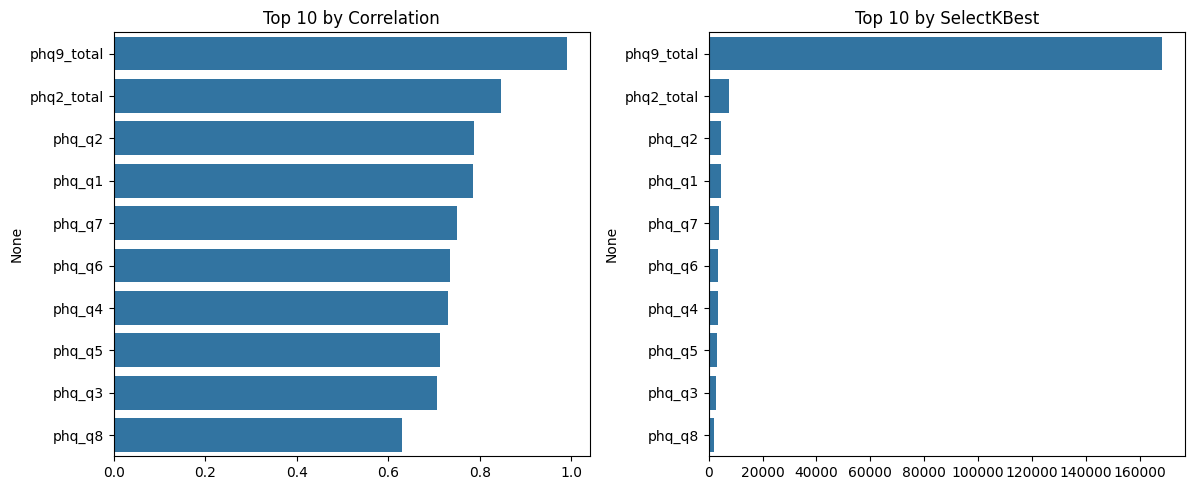

In [ ]:
try:
    # Step 1: Clean data
    df_clean = df.dropna()

    if 'phq8_total' not in df_clean.columns:
        raise ValueError("Target column 'phq8_total' not found in DataFrame.")

    # Separate features and target
    X = df_clean.drop(columns=['phq8_total'])
    y = df_clean['phq8_total']

    # Ensure only numeric columns
    X_numeric = X.select_dtypes(include=[np.number])

    if X_numeric.shape[1] == 0:
        raise ValueError("No numeric features found for analysis.")

    # --------- 1. Correlation Method ---------
    try:
        correlation = X_numeric.corrwith(y).abs().sort_values(ascending=False)
        top_corr_features = correlation.head(10)
        print("\n🔹 Top 10 Features by Correlation:\n", top_corr_features)
    except Exception as e:
        print("Error during correlation-based selection:", str(e))

    # --------- 2. SelectKBest Method ---------
    try:
        selector = SelectKBest(score_func=f_regression, k=10)
        selector.fit(X_numeric, y)
        kbest_features = X_numeric.columns[selector.get_support()]
        kbest_scores = selector.scores_[selector.get_support()]
        top_kbest = pd.Series(kbest_scores, index=kbest_features).sort_values(ascending=False)
        print("\n🔹 Top 10 Features by SelectKBest:\n", top_kbest)
    except Exception as e:
        print("Error during SelectKBest feature selection:", str(e))

    # --------- 3. Random Forest Importance ---------
    try:
        X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)
        model = RandomForestRegressor(random_state=42)
        model.fit(X_train, y_train)
        rf_importance = pd.Series(model.feature_importances_, index=X_numeric.columns)
        top_rf_features = rf_importance.sort_values(ascending=False).head(10)
        print("\n🔹 Top 10 Features by Random Forest Importance:\n", top_rf_features)
    except Exception as e:
        print("Error during Random Forest feature importance:", str(e))

    # --------- Visualization (Optional) ---------
    try:
        plt.figure(figsize=(18, 5))

        plt.subplot(1, 3, 1)
        sns.barplot(x=top_corr_features.values, y=top_corr_features.index)
        plt.title('Top 10 by Correlation')

        plt.subplot(1, 3, 2)
        sns.barplot(x=top_kbest.values, y=top_kbest.index)
        plt.title('Top 10 by SelectKBest')
        #output_path = os.path.join(output_folder, 'distribution-outlier.png')
        

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Error during plotting:", str(e))

except Exception as e:
    print("Fatal error during processing:", str(e))